# Statistical Analysis — Linear Mixed-Effects Models

Formal group-level statistical tests for three directional hypotheses about cardiovascular adaptation across 9 training sessions over 3 weeks.

- **H1:** Mean heart rate during a session decreases over sessions
- **H2:** The rate of HR increase during run intervals decreases over sessions
- **H3:** The rate of HR decrease during walk/recovery intervals increases (becomes more negative) over sessions

**Method:** Linear mixed-effects models with session number as fixed effect and participant as random intercept. One-tailed tests matching the directional hypotheses.

**Participants:** Suspects 2, 3, 4 (9 sessions each) and Suspect 5 (7 sessions). Suspect 6 excluded due to insufficient data quality.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import statsmodels.formula.api as smf
from datetime import datetime


# Protocol definition
RUN_DURATIONS = [70, 80, 90, 100, 110, 120]
WALK_DURATION = 60
PROTOCOL_DURATION_SEC = sum(RUN_DURATIONS) + WALK_DURATION * len(RUN_DURATIONS)  # 930s

# Suspect config: suspect_id -> run_start_sec
SUSPECTS = {
    "suspect_2": 60,
    "suspect_3": 60,
    "suspect_4": 60,
    "suspect_5": 180,
}

SUSPECT_COLORS = {
    "suspect_2": "#2171b5",
    "suspect_3": "#238b45",
    "suspect_4": "#cb181d",
    "suspect_5": "#e6550d",
}


def build_interval_schedule(run_start_sec: float) -> list:
    schedule, cursor = [], run_start_sec
    for run_dur in RUN_DURATIONS:
        schedule.append({"start": cursor, "end": cursor + run_dur, "phase": "run"})
        cursor += run_dur
        schedule.append({"start": cursor, "end": cursor + WALK_DURATION, "phase": "walk"})
        cursor += WALK_DURATION
    return schedule


def parse_run_data(records: list):
    """Parse per_second_data into elapsed-time and HR numpy arrays."""
    if not records:
        return np.array([]), np.array([])
    t0_abs = datetime.fromisoformat(records[0]["timestamp"])
    times, hrs = [], []
    for rec in records:
        t_abs = datetime.fromisoformat(rec["timestamp"])
        times.append((t_abs - t0_abs).total_seconds())
        hrs.append(rec["heart_rate"])
    return np.array(times), np.array(hrs)


def _draw_grid(ax):
    ax.set_axisbelow(True)
    ax.grid(axis="both", color="grey", linestyle="--", linewidth=0.5, alpha=0.4)

In [2]:
# Build session-level dataframe
rows_session = []

for suspect_id, run_start_sec in SUSPECTS.items():
    with open(f"../processed/{suspect_id}.json") as f:
        data = json.load(f)

    schedule = build_interval_schedule(run_start_sec)
    run_segs = [s for s in schedule if s["phase"] == "run"]
    walk_segs = [s for s in schedule if s["phase"] == "walk"]

    for session_idx, run in enumerate(data["runs"]):
        times, hrs = parse_run_data(run["per_second_data"])
        if len(times) == 0:
            continue

        # Mean HR over protocol window
        protocol_end = run_start_sec + PROTOCOL_DURATION_SEC
        mask = (times >= run_start_sec) & (times <= protocol_end)
        mean_hr = float(np.mean(hrs[mask])) if np.any(mask) else np.nan

        # Rise slopes (bpm/s) per run interval, then average
        rise_slopes = []
        for seg in run_segs:
            seg_mask = (times >= seg["start"]) & (times <= seg["end"])
            if np.sum(seg_mask) >= 2:
                slope = np.polyfit(times[seg_mask], hrs[seg_mask], 1)[0]
                rise_slopes.append(slope)
        mean_rise_slope = float(np.mean(rise_slopes)) if rise_slopes else np.nan

        # Recovery slopes (bpm/s) per walk interval, then average
        recovery_slopes = []
        for seg in walk_segs:
            seg_mask = (times >= seg["start"]) & (times <= seg["end"])
            if np.sum(seg_mask) >= 2:
                slope = np.polyfit(times[seg_mask], hrs[seg_mask], 1)[0]
                recovery_slopes.append(slope)
        mean_recovery_slope = float(np.mean(recovery_slopes)) if recovery_slopes else np.nan

        rows_session.append({
            "suspect_id": suspect_id,
            "session": session_idx + 1,
            "mean_hr": mean_hr,
            "mean_rise_slope": mean_rise_slope,
            "mean_recovery_slope": mean_recovery_slope,
        })

df_session = pd.DataFrame(rows_session)
print(f"Session-level dataframe: {df_session.shape[0]} observations, {df_session['suspect_id'].nunique()} participants")
df_session.head(10)

Session-level dataframe: 34 observations, 4 participants


,suspect_id,session,mean_hr,mean_rise_slope,mean_recovery_slope
0,suspect_2,1,173.938578,0.344095,-0.185941
1,suspect_2,2,170.684267,0.422675,-0.329763
2,suspect_2,3,151.408649,0.246478,-0.287245
3,suspect_2,4,167.109544,0.262315,-0.384057
4,suspect_2,5,169.045210,0.377278,-0.352541
5,suspect_2,6,168.718447,0.344514,-0.251436
6,suspect_2,7,163.037879,0.324207,-0.341874
7,suspect_2,8,162.712903,0.417970,-0.387817
8,suspect_2,9,164.939525,0.404411,-0.441561
9,suspect_3,1,160.398496,0.435466,-0.482082


In [3]:
# Build interval-level dataframe
rows_interval = []

for suspect_id, run_start_sec in SUSPECTS.items():
    with open(f"../processed/{suspect_id}.json") as f:
        data = json.load(f)

    schedule = build_interval_schedule(run_start_sec)
    run_segs = [s for s in schedule if s["phase"] == "run"]
    walk_segs = [s for s in schedule if s["phase"] == "walk"]

    for session_idx, run in enumerate(data["runs"]):
        times, hrs = parse_run_data(run["per_second_data"])
        if len(times) == 0:
            continue

        for interval_idx, (run_seg, walk_seg) in enumerate(zip(run_segs, walk_segs)):
            # Rise slope
            run_mask = (times >= run_seg["start"]) & (times <= run_seg["end"])
            rise_slope = np.nan
            if np.sum(run_mask) >= 2:
                rise_slope = float(np.polyfit(times[run_mask], hrs[run_mask], 1)[0])

            # Recovery slope
            walk_mask = (times >= walk_seg["start"]) & (times <= walk_seg["end"])
            recovery_slope = np.nan
            if np.sum(walk_mask) >= 2:
                recovery_slope = float(np.polyfit(times[walk_mask], hrs[walk_mask], 1)[0])

            rows_interval.append({
                "suspect_id": suspect_id,
                "session": session_idx + 1,
                "interval": interval_idx + 1,
                "rise_slope": rise_slope,
                "recovery_slope": recovery_slope,
            })

df_interval = pd.DataFrame(rows_interval)
print(f"Interval-level dataframe: {df_interval.shape[0]} observations, {df_interval['suspect_id'].nunique()} participants")
print(f"Non-null rise slopes: {df_interval['rise_slope'].notna().sum()}, recovery slopes: {df_interval['recovery_slope'].notna().sum()}")
df_interval.head(10)

Interval-level dataframe: 204 observations, 4 participants
Non-null rise slopes: 204, recovery slopes: 204


,suspect_id,session,interval,rise_slope,recovery_slope
0,suspect_2,1,1,0.996809,-0.186246
1,suspect_2,1,2,0.227039,-0.022478
2,suspect_2,1,3,0.226759,-0.284251
3,suspect_2,1,4,0.201368,-0.306240
4,suspect_2,1,5,0.232449,-0.266528
5,suspect_2,1,6,0.180144,-0.049903
6,suspect_2,2,1,1.097445,-0.378151
7,suspect_2,2,2,0.489311,-0.267977
8,suspect_2,2,3,0.320221,-0.252678
9,suspect_2,2,4,0.224728,-0.297194


---

## Hypothesis 1: Mean Heart Rate Decreases Over Sessions

**Dependent variable:** Mean HR computed across the active protocol window (run + walk intervals) per session.

**Model:** `mean_hr ~ session`, with random intercept for `suspect_id`.

**Directional hypothesis:** The session coefficient is negative (mean HR decreases as training progresses).

In [4]:
# H1: Linear mixed-effects model — Mean HR ~ Session
model_h1 = smf.mixedlm("mean_hr ~ session", df_session, groups=df_session["suspect_id"])
result_h1 = model_h1.fit()
print(result_h1.summary())

# One-tailed test (H1: coefficient < 0)
coef_h1 = result_h1.params["session"]
pval_h1_two = result_h1.pvalues["session"]
pval_h1_one = pval_h1_two / 2 if coef_h1 < 0 else 1 - pval_h1_two / 2
print(f"\nSession coefficient: {coef_h1:.4f} bpm/session")
print(f"One-tailed p-value (H1: coef < 0): {pval_h1_one:.4f}")
print(f"Interpretation: {'Supported' if pval_h1_one < 0.05 and coef_h1 < 0 else 'Not supported'} at alpha = 0.05")

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: mean_hr  
No. Observations: 34      Method:             REML     
No. Groups:       4       Scale:              34.6394  
Min. group size:  7       Log-Likelihood:     -111.8556
Max. group size:  9       Converged:          Yes      
Mean group size:  8.5                                  
-------------------------------------------------------
           Coef.  Std.Err.   z    P>|z|  [0.025  0.975]
-------------------------------------------------------
Intercept 167.181    6.232 26.825 0.000 154.966 179.396
session    -0.737    0.408 -1.804 0.071  -1.537   0.063
Group Var 136.210   20.510                             


Session coefficient: -0.7365 bpm/session
One-tailed p-value (H1: coef < 0): 0.0356
Interpretation: Supported at alpha = 0.05


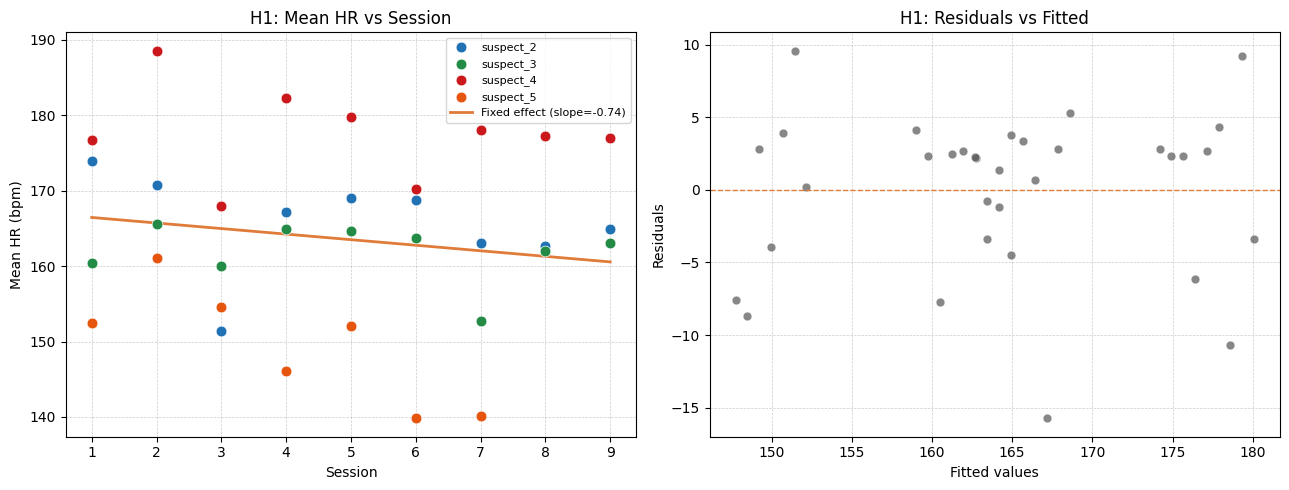

In [5]:
# H1: Diagnostic plots
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: scatter + model line
ax = axes[0]
_draw_grid(ax)
for sid in SUSPECTS:
    subset = df_session[df_session["suspect_id"] == sid]
    ax.scatter(subset["session"], subset["mean_hr"], color=SUSPECT_COLORS[sid],
               s=60, edgecolors="white", linewidths=0.5, label=sid, zorder=3)

# Fixed-effect line
x_line = np.linspace(1, 9, 100)
y_line = result_h1.params["Intercept"] + result_h1.params["session"] * x_line
ax.plot(x_line, y_line, color="#e07b39", linewidth=2, label=f"Fixed effect (slope={coef_h1:.2f})")

ax.set_xlabel("Session")
ax.set_ylabel("Mean HR (bpm)")
ax.set_title("H1: Mean HR vs Session")
ax.legend(fontsize=8, loc="best")

# Right: residuals
ax = axes[1]
_draw_grid(ax)
residuals = result_h1.resid
fitted = result_h1.fittedvalues
ax.scatter(fitted, residuals, color="#555555", s=40, alpha=0.7, edgecolors="white", linewidths=0.5)
ax.axhline(0, color="#e07b39", linewidth=1, linestyle="--")
ax.set_xlabel("Fitted values")
ax.set_ylabel("Residuals")
ax.set_title("H1: Residuals vs Fitted")

plt.tight_layout()
plt.show()

---

## Hypothesis 2: The Rate of HR Increase During Run Intervals Decreases Over Sessions

**Dependent variable:** Rise slope (bpm/s) computed by fitting a line to HR within each run interval. Averaged across 6 intervals for the session-level model.

**Session-level model:** `mean_rise_slope ~ session`, with random intercept for `suspect_id`.

**Interval-level model:** `rise_slope ~ session`, with random intercept for `suspect_id`.

**Directional hypothesis:** The session coefficient is negative (HR rises less steeply with training).

In [6]:
# H2: Session-level LMM — Mean Rise Slope ~ Session
model_h2 = smf.mixedlm("mean_rise_slope ~ session", df_session, groups=df_session["suspect_id"])
result_h2 = model_h2.fit()
print("=== Session-level model ===")
print(result_h2.summary())

coef_h2 = result_h2.params["session"]
pval_h2_two = result_h2.pvalues["session"]
pval_h2_one = pval_h2_two / 2 if coef_h2 < 0 else 1 - pval_h2_two / 2
print(f"\nSession coefficient: {coef_h2:.6f} bpm/s/session")
print(f"One-tailed p-value (H2: coef < 0): {pval_h2_one:.4f}")
print(f"Interpretation: {'Supported' if pval_h2_one < 0.05 and coef_h2 < 0 else 'Not supported'} at alpha = 0.05")

# H2: Interval-level LMM (supplementary)
df_interval_rise = df_interval.dropna(subset=["rise_slope"])
model_h2_int = smf.mixedlm("rise_slope ~ session", df_interval_rise, groups=df_interval_rise["suspect_id"])
result_h2_int = model_h2_int.fit()
print("\n=== Interval-level model (supplementary) ===")
print(result_h2_int.summary())

coef_h2_int = result_h2_int.params["session"]
pval_h2_int_two = result_h2_int.pvalues["session"]
pval_h2_int_one = pval_h2_int_two / 2 if coef_h2_int < 0 else 1 - pval_h2_int_two / 2
print(f"\nSession coefficient: {coef_h2_int:.6f} bpm/s/session")
print(f"One-tailed p-value (H2: coef < 0): {pval_h2_int_one:.4f}")

=== Session-level model ===
            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: mean_rise_slope
No. Observations: 34      Method:             REML           
No. Groups:       4       Scale:              0.0096         
Min. group size:  7       Log-Likelihood:     19.6645        
Max. group size:  9       Converged:          Yes            
Mean group size:  8.5                                        
---------------------------------------------------------------
             Coef.   Std.Err.     z     P>|z|   [0.025   0.975]
---------------------------------------------------------------
Intercept    0.230      0.089   2.584   0.010    0.056    0.405
session      0.011      0.007   1.565   0.118   -0.003    0.024
Group Var    0.027      0.241                                  


Session coefficient: 0.010645 bpm/s/session
One-tailed p-value (H2: coef < 0): 0.9412
Interpretation: Not supported at alpha = 0.05

=== Interval-level model (suppl

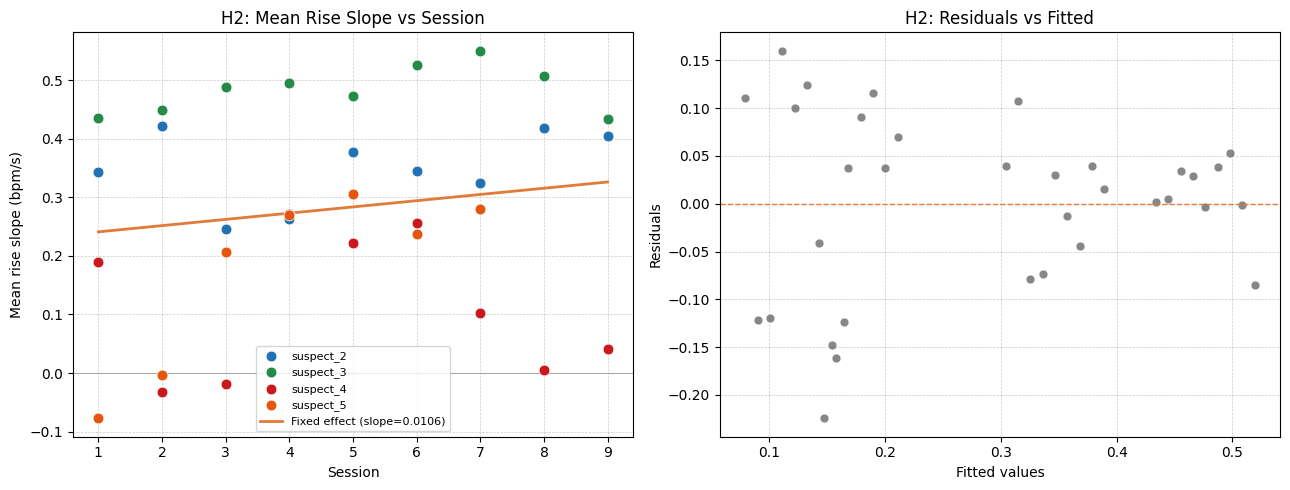

In [7]:
# H2: Diagnostic plots
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: scatter + model line (session-level)
ax = axes[0]
_draw_grid(ax)
for sid in SUSPECTS:
    subset = df_session[df_session["suspect_id"] == sid]
    ax.scatter(subset["session"], subset["mean_rise_slope"], color=SUSPECT_COLORS[sid],
               s=60, edgecolors="white", linewidths=0.5, label=sid, zorder=3)

x_line = np.linspace(1, 9, 100)
y_line = result_h2.params["Intercept"] + result_h2.params["session"] * x_line
ax.plot(x_line, y_line, color="#e07b39", linewidth=2, label=f"Fixed effect (slope={coef_h2:.4f})")
ax.axhline(0, color="#aaaaaa", linewidth=0.8, linestyle="-")

ax.set_xlabel("Session")
ax.set_ylabel("Mean rise slope (bpm/s)")
ax.set_title("H2: Mean Rise Slope vs Session")
ax.legend(fontsize=8, loc="best")

# Right: residuals
ax = axes[1]
_draw_grid(ax)
residuals = result_h2.resid
fitted = result_h2.fittedvalues
ax.scatter(fitted, residuals, color="#555555", s=40, alpha=0.7, edgecolors="white", linewidths=0.5)
ax.axhline(0, color="#e07b39", linewidth=1, linestyle="--")
ax.set_xlabel("Fitted values")
ax.set_ylabel("Residuals")
ax.set_title("H2: Residuals vs Fitted")

plt.tight_layout()
plt.show()

---

## Hypothesis 3: The Rate of HR Decrease During Walk/Recovery Intervals Increases Over Sessions

**Dependent variable:** Recovery slope (bpm/s), which is negative (HR falling). A more negative value means faster recovery.

**Session-level model:** `mean_recovery_slope ~ session`, with random intercept for `suspect_id`.

**Interval-level model:** `recovery_slope ~ session`, with random intercept for `suspect_id`.

**Directional hypothesis:** The session coefficient is negative (recovery slope becomes more negative, i.e. faster recovery, with training).

In [8]:
# H3: Session-level LMM — Mean Recovery Slope ~ Session
model_h3 = smf.mixedlm("mean_recovery_slope ~ session", df_session, groups=df_session["suspect_id"])
result_h3 = model_h3.fit()
print("=== Session-level model ===")
print(result_h3.summary())

coef_h3 = result_h3.params["session"]
pval_h3_two = result_h3.pvalues["session"]
pval_h3_one = pval_h3_two / 2 if coef_h3 < 0 else 1 - pval_h3_two / 2
print(f"\nSession coefficient: {coef_h3:.6f} bpm/s/session")
print(f"One-tailed p-value (H3: coef < 0): {pval_h3_one:.4f}")
print(f"Interpretation: {'Supported' if pval_h3_one < 0.05 and coef_h3 < 0 else 'Not supported'} at alpha = 0.05")

# H3: Interval-level LMM (supplementary)
df_interval_rec = df_interval.dropna(subset=["recovery_slope"])
model_h3_int = smf.mixedlm("recovery_slope ~ session", df_interval_rec, groups=df_interval_rec["suspect_id"])
result_h3_int = model_h3_int.fit()
print("\n=== Interval-level model (supplementary) ===")
print(result_h3_int.summary())

coef_h3_int = result_h3_int.params["session"]
pval_h3_int_two = result_h3_int.pvalues["session"]
pval_h3_int_one = pval_h3_int_two / 2 if coef_h3_int < 0 else 1 - pval_h3_int_two / 2
print(f"\nSession coefficient: {coef_h3_int:.6f} bpm/s/session")
print(f"One-tailed p-value (H3: coef < 0): {pval_h3_int_one:.4f}")

=== Session-level model ===
              Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: mean_recovery_slope
No. Observations: 34      Method:             REML               
No. Groups:       4       Scale:              0.0106             
Min. group size:  7       Log-Likelihood:     17.3392            
Max. group size:  9       Converged:          Yes                
Mean group size:  8.5                                            
-------------------------------------------------------------------
               Coef.    Std.Err.     z      P>|z|   [0.025   0.975]
-------------------------------------------------------------------
Intercept      -0.195      0.118   -1.648   0.099   -0.427    0.037
session        -0.014      0.007   -1.960   0.050   -0.028   -0.000
Group Var       0.050      0.428                                   


Session coefficient: -0.013994 bpm/s/session
One-tailed p-value (H3: coef < 0): 0.0250
Interpretation: Supported a

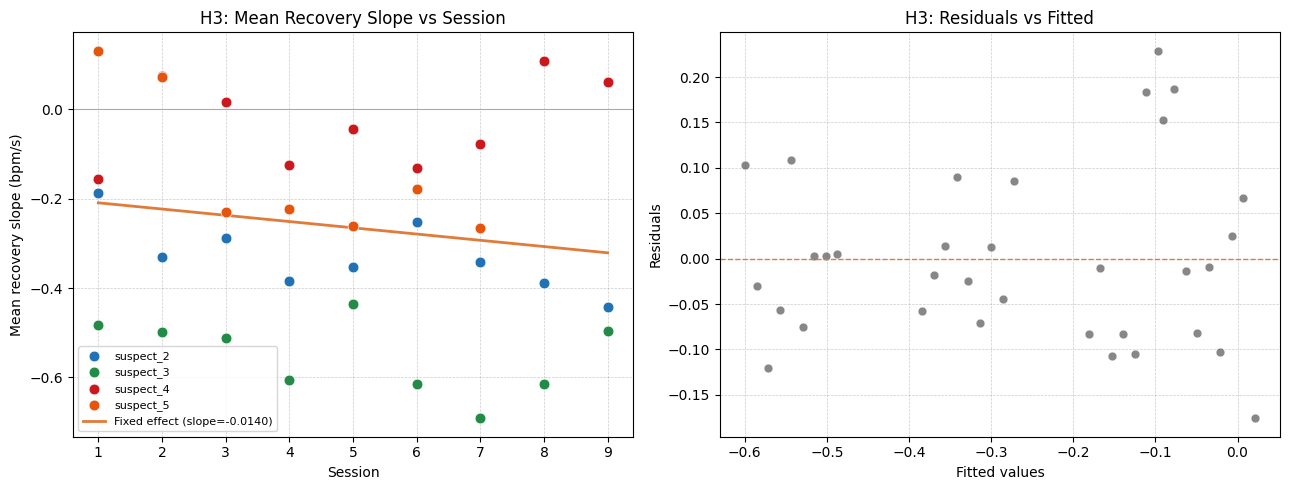

In [9]:
# H3: Diagnostic plots
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: scatter + model line (session-level)
ax = axes[0]
_draw_grid(ax)
for sid in SUSPECTS:
    subset = df_session[df_session["suspect_id"] == sid]
    ax.scatter(subset["session"], subset["mean_recovery_slope"], color=SUSPECT_COLORS[sid],
               s=60, edgecolors="white", linewidths=0.5, label=sid, zorder=3)

x_line = np.linspace(1, 9, 100)
y_line = result_h3.params["Intercept"] + result_h3.params["session"] * x_line
ax.plot(x_line, y_line, color="#e07b39", linewidth=2, label=f"Fixed effect (slope={coef_h3:.4f})")
ax.axhline(0, color="#aaaaaa", linewidth=0.8, linestyle="-")

ax.set_xlabel("Session")
ax.set_ylabel("Mean recovery slope (bpm/s)")
ax.set_title("H3: Mean Recovery Slope vs Session")
ax.legend(fontsize=8, loc="best")

# Right: residuals
ax = axes[1]
_draw_grid(ax)
residuals = result_h3.resid
fitted = result_h3.fittedvalues
ax.scatter(fitted, residuals, color="#555555", s=40, alpha=0.7, edgecolors="white", linewidths=0.5)
ax.axhline(0, color="#e07b39", linewidth=1, linestyle="--")
ax.set_xlabel("Fitted values")
ax.set_ylabel("Residuals")
ax.set_title("H3: Residuals vs Fitted")

plt.tight_layout()
plt.show()

---

## Summary

In [10]:
# Summary table
summary_rows = []

for label, result, coef, pval_one, level in [
    ("H1: Mean HR", result_h1, coef_h1, pval_h1_one, "session"),
    ("H2: Rise slope (session)", result_h2, coef_h2, pval_h2_one, "session"),
    ("H2: Rise slope (interval)", result_h2_int, coef_h2_int, pval_h2_int_one, "interval"),
    ("H3: Recovery slope (session)", result_h3, coef_h3, pval_h3_one, "session"),
    ("H3: Recovery slope (interval)", result_h3_int, coef_h3_int, pval_h3_int_one, "interval"),
]:
    se = result.bse["session"]
    ci_low = coef - 1.96 * se
    ci_high = coef + 1.96 * se
    supported = "Yes" if pval_one < 0.05 and coef < 0 else "No"

    summary_rows.append({
        "Hypothesis": label,
        "Level": level,
        "Coefficient": f"{coef:.4f}",
        "SE": f"{se:.4f}",
        "95% CI": f"[{ci_low:.4f}, {ci_high:.4f}]",
        "p (one-tailed)": f"{pval_one:.4f}",
        "Supported (\u03b1=0.05)": supported,
    })

df_summary = pd.DataFrame(summary_rows)
df_summary

,Hypothesis,Level,Coefficient,SE,95% CI,p (one-tailed),Supported (α=0.05)
0,H1: Mean HR,session,-0.7365,0.4082,"[-1.5366, 0.0635]",0.0356,Yes
1,H2: Rise slope (session),session,0.0106,0.0068,"[-0.0027, 0.0240]",0.9412,No
2,H2: Rise slope (interval),interval,0.0106,0.0054,"[0.0001, 0.0211]",0.9758,No
3,H3: Recovery slope (session),session,-0.0140,0.0071,"[-0.0280, -0.0000]",0.0250,Yes
4,H3: Recovery slope (interval),interval,-0.0139,0.0041,"[-0.0219, -0.0059]",0.0003,Yes
